# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Damasoumana1/flyrank-ml-internship-july2026/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Research question:** Can observed search-performance signals rank webpages that deserve content-refresh review, using only information available at decision time?

**Decision supported:** help a content or SEO reviewer decide which pseudonymized page records to inspect first.

**Output:** a ranked decision-support queue with a priority score, one reason code, and one recommended action.

**Cost of a wrong call:** an editor may spend time reviewing a stable page, while a genuinely declining page may be missed. The queue is therefore a review aid, not an automatic publishing, deletion, or ranking instruction.

**Why ML may help:** a transparent rule is an important baseline, but several noisy signals may interact in ways that are difficult to maintain as a hand-written rule. The capstone will only claim observed, measured, directional results on this dataset and protocol.


In [4]:
# Setup and reproducibility
import json
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import userdata
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
Path("work/outputs").mkdir(parents=True, exist_ok=True)
Path("work/outputs/figures").mkdir(parents=True, exist_ok=True)

HF_TOKEN = userdata.get("HF_TOKEN")
if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN is missing from Colab Secrets.")

con = duckdb.connect()
con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")
con.execute("SET http_retries = 3")
con.execute("SET http_timeout = 60")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE HUGGINGFACE, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT_MARCH = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"
FACT_APRIL = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-04/*.parquet')"
ANALYSIS_MONTH = "2026-03"
OUTCOME_MONTH = "2026-04"

print({"analysis_month": ANALYSIS_MONTH, "outcome_month": OUTCOME_MONTH, "seed": SEED})


{'analysis_month': '2026-03', 'outcome_month': '2026-04', 'seed': 42}


## 2. Data

**Release:** FlyRank internship warehouse, accessed through the gated Hugging Face release.

**Tables used:** the March and April partitions of `fact_content_daily_performance`.

**Unit of analysis:** one row per `client_hash_id × content_hash_id` pair with March features and an April outcome proxy.

**Decision window:** features are aggregated from March 2026. The outcome window is April 2026 and is used only to construct the evaluation target.

**Public-safe exclusions:** identifiers are used only for grouping, joining and evaluation; they are not model features. No client names, domains, URLs, queries or credentials are loaded. Future April fields and any label-derived fields are excluded from the model feature matrix.

**Important limitation:** this is a single March → April window. A multi-window evaluation would be stronger and is listed as a next step in the paper.


In [5]:
# Build a compact feature frame in DuckDB. The remote daily rows are aggregated before pandas/modeling.
FEATURES_SQL = f"""
WITH march_features AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(COALESCE(gsc_impressions, 0)) AS march_impressions,
        SUM(COALESCE(gsc_clicks, 0)) AS march_clicks,
        AVG(NULLIF(gsc_avg_position, 0)) AS march_avg_position,
        SUM(CASE WHEN COALESCE(gsc_impressions, 0) > 0 THEN 1 ELSE 0 END) AS march_days_with_impressions,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN COALESCE(ga4_sessions, 0) ELSE 0 END) AS march_ga4_sessions,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) AS march_ga4_available_days
    FROM {FACT_MARCH}
    GROUP BY 1, 2
),
april_outcomes AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(COALESCE(gsc_impressions, 0)) AS april_impressions
    FROM {FACT_APRIL}
    GROUP BY 1, 2
)
SELECT
    m.*,
    a.april_impressions,
    CAST(a.april_impressions < 0.8 * m.march_impressions AS INTEGER) AS is_declining_next30
FROM march_features m
INNER JOIN april_outcomes a USING (client_hash_id, content_hash_id)
WHERE m.march_impressions > 0
"""

feature_frame = con.sql(FEATURES_SQL).df()
feature_frame["is_declining_next30"] = pd.to_numeric(feature_frame["is_declining_next30"], errors="coerce").astype(int)
feature_frame["march_avg_position"] = pd.to_numeric(feature_frame["march_avg_position"], errors="coerce")

assert len(feature_frame) > 0
assert set(feature_frame["is_declining_next30"].unique()).issubset({0, 1})

print("Rows in feature frame:", len(feature_frame))
print("Observed future-decline proxy base rate:", round(float(feature_frame["is_declining_next30"].mean()), 4))
print("Feature frame columns:", list(feature_frame.columns))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows in feature frame: 176737
Observed future-decline proxy base rate: 0.5319
Feature frame columns: ['client_hash_id', 'content_hash_id', 'march_impressions', 'march_clicks', 'march_avg_position', 'march_days_with_impressions', 'march_ga4_sessions', 'march_ga4_available_days', 'april_impressions', 'is_declining_next30']


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The target is an **operational future-decline proxy**: April impressions are below 80% of March impressions. It is constructed from the future window for evaluation; it is never used in the score as a feature.

The model feature set contains only March information:

- `log_march_impressions`
- `log_march_clicks`
- `march_avg_position`
- `march_days_with_impressions`
- `log_march_ga4_sessions`
- `march_ga4_available_days`
- `march_position_missing`

The transparent ML-07 rule is the baseline: pages with at least 100 March impressions receive a volume score, and pages with at least 100 impressions and average position 0–10 receive a doubled protection score. The baseline is a prioritization rule, not a probability.

The validation split is a client-group holdout: records from a client are kept entirely in train or test. This tests generalization to unseen pseudonymized clients, but it does not replace a multi-window time split. All models and the baseline are evaluated on the same held-out rows.


In [6]:
# Create legal model features from March only, then make one client-group holdout.
feature_frame["log_march_impressions"] = np.log1p(feature_frame["march_impressions"])
feature_frame["log_march_clicks"] = np.log1p(feature_frame["march_clicks"])
feature_frame["log_march_ga4_sessions"] = np.log1p(feature_frame["march_ga4_sessions"])
feature_frame["march_position_missing"] = feature_frame["march_avg_position"].isna().astype(int)

MODEL_FEATURES = [
    "log_march_impressions",
    "log_march_clicks",
    "march_avg_position",
    "march_days_with_impressions",
    "log_march_ga4_sessions",
    "march_ga4_available_days",
    "march_position_missing",
]
TARGET = "is_declining_next30"
GROUP = "client_hash_id"

X = feature_frame[MODEL_FEATURES].copy()
y = feature_frame[TARGET].astype(int).copy()
groups = feature_frame[GROUP].copy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

def precision_at_k(labels, scores, k=50):
    k = min(k, len(labels))
    order = np.argsort(-np.asarray(scores))[:k]
    return float(np.asarray(labels)[order].mean()) if k else float("nan")

print({
    "train_rows": len(train_idx),
    "test_rows": len(test_idx),
    "train_clients": groups.iloc[train_idx].nunique(),
    "test_clients": groups.iloc[test_idx].nunique(),
    "test_base_rate": round(float(y_test.mean()), 4),
})


{'train_rows': 138309, 'test_rows': 38428, 'train_clients': 37, 'test_clients': 10, 'test_base_rate': 0.4538}


In [7]:
# Train readable and stronger models. Imputation is fitted only on the training data.
preprocess = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), MODEL_FEATURES),
    ],
    remainder="drop",
)

models = {
    "logistic_regression": Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
    "random_forest": Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
        )),
    ]),
}

model_scores = {}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    scores = model.predict_proba(X_test)[:, 1]
    model_scores[name] = scores
    results.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, scores),
        "average_precision": average_precision_score(y_test, scores),
        "precision_at_10": precision_at_k(y_test, scores, 10),
        "precision_at_20": precision_at_k(y_test, scores, 20),
        "precision_at_50": precision_at_k(y_test, scores, 50),
    })

# ML-07 baseline evaluated on the same held-out test rows.
baseline_frame = feature_frame.iloc[test_idx].copy()
baseline_position = baseline_frame["march_avg_position"].notna() & (baseline_frame["march_avg_position"] > 0)
baseline_high_visibility = baseline_position & (baseline_frame["march_avg_position"] <= 10)
baseline_high_volume = baseline_frame["march_impressions"] >= 100
baseline_scores = np.where(
    baseline_high_volume & baseline_high_visibility,
    2.0 * baseline_frame["march_impressions"],
    np.where(baseline_high_volume, baseline_frame["march_impressions"], 0.0),
)
results.insert(0, {
    "model": "ml07_transparent_baseline",
    "roc_auc": roc_auc_score(y_test, baseline_scores),
    "average_precision": average_precision_score(y_test, baseline_scores),
    "precision_at_10": precision_at_k(y_test, baseline_scores, 10),
    "precision_at_20": precision_at_k(y_test, baseline_scores, 20),
    "precision_at_50": precision_at_k(y_test, baseline_scores, 50),
})

results_df = pd.DataFrame(results)
print(results_df.round(4).to_string(index=False))
print("Test base rate:", round(float(y_test.mean()), 4))


                    model  roc_auc  average_precision  precision_at_10  precision_at_20  precision_at_50
ml07_transparent_baseline   0.4747             0.4227              0.2              0.2             0.16
      logistic_regression   0.5792             0.5064              0.7              0.6             0.54
            random_forest   0.5899             0.5314              0.9              0.9             0.86
Test base rate: 0.4538


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The table below is the primary result: baseline and learned models are scored on the same client-held-out test rows and the same future-decline proxy. The final paper must use the numbers from this fresh run, not the exploratory 30,000-row starter-dataset result from ML-03.


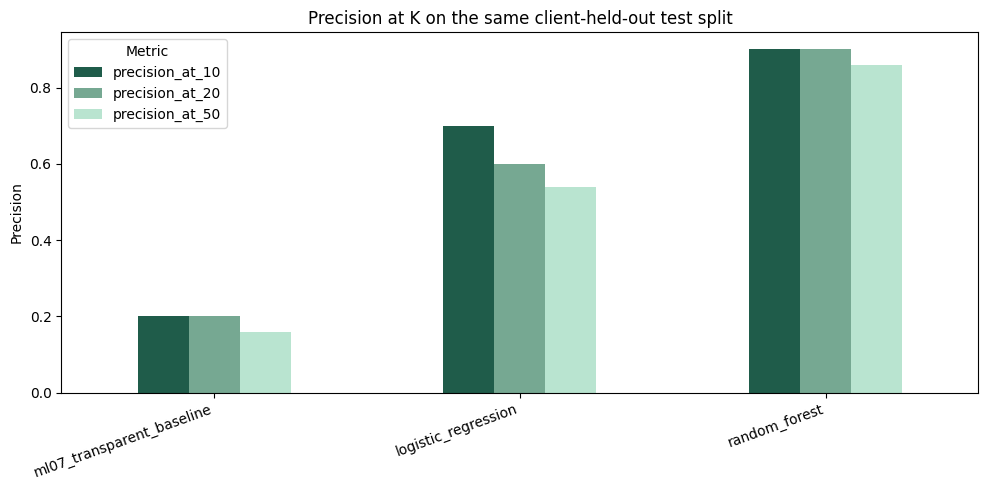

In [8]:
# Save the honest comparison table and a chart for the paper.
results_df.to_json("work/outputs/capstone_metrics.json", orient="records", indent=2)

plot_df = results_df.set_index("model")
ax = plot_df[["precision_at_10", "precision_at_20", "precision_at_50"]].plot(
    kind="bar", figsize=(10, 5), color=["#1F5C4A", "#76A892", "#B9E4D0"]
)
ax.set_title("Precision at K on the same client-held-out test split")
ax.set_ylabel("Precision")
ax.set_xlabel("")
ax.legend(title="Metric")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("work/outputs/figures/capstone_model_comparison.png", dpi=160)
plt.show()


## 5. Limitations

*What this work cannot claim.*

This analysis cannot establish that a page will improve after a refresh, explain Google's ranking algorithm, or prove a causal effect of any editorial action. The target is an operational future-decline proxy based on a 20% month-over-month impression change, not a human-labelled editorial outcome.

The current final protocol uses one March → April outcome window and a client-group holdout. That is useful for checking generalization to held-out clients, but it does not demonstrate stability across multiple time periods. History depth and GA4 availability also differ across clients, and GA4 zeros are treated as unavailable when the `ga4_data_available` flag is false.

The most important next validation is to repeat the full frame construction over several non-overlapping month pairs, choose all modeling decisions before touching the final sealed month, and report whether the model beats the transparent baseline consistently rather than on one split.


In [9]:
# Explicit leakage attack: add a future-derived feature, show the suspicious result, then remove it.
leaky_X = X.copy()
leaky_X["future_decline_leak"] = y.to_numpy()
leaky_train, leaky_test = leaky_X.iloc[train_idx], leaky_X.iloc[test_idx]

leaky_model = Pipeline([
    ("preprocess", ColumnTransformer([
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), list(leaky_X.columns)),
    ], remainder="drop")),
    ("model", RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)),
])
leaky_model.fit(leaky_train, y_train)
leaky_scores = leaky_model.predict_proba(leaky_test)[:, 1]

print("Leaky precision@50:", round(precision_at_k(y_test, leaky_scores, 50), 4))
print("Honest best-model precision@50:", round(float(results_df.loc[results_df["model"] == "random_forest", "precision_at_50"].iloc[0]), 4))
print("Leak column removed from honest MODEL_FEATURES:", "future_decline_leak" not in MODEL_FEATURES)


Leaky precision@50: 1.0
Honest best-model precision@50: 0.86
Leak column removed from honest MODEL_FEATURES: True


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

For the usable queue, the selected model should be retrained on the full March feature frame only after the evaluation protocol is fixed. The queue is a reviewer aid: each recommendation includes a score, one reason code, and one action label. The output is not an automatic content change.


In [10]:
from pathlib import Path
import numpy as np
import pandas as pd

# Create the output folder before writing the recommendation file.
Path("work/outputs").mkdir(parents=True, exist_ok=True)

selected_model_name = "random_forest"
scoring_scope = None
scoring_method = None

# Case 1: use the Random Forest if it was fitted successfully in cell 5.
if "models" in globals() and selected_model_name in models:
    candidate_model = models[selected_model_name]
    candidate_estimator = candidate_model.named_steps.get("model")

    if hasattr(candidate_estimator, "estimators_") and len(candidate_estimator.estimators_) > 0:
        scoring_frame = feature_frame.copy()
        all_scores = candidate_model.predict_proba(X)[:, 1]
        scoring_scope = "all_march_rows"
        scoring_method = "random_forest_evaluation_model"

# Case 2: use stored test predictions if the model object is unavailable
# or was damaged by the previous KeyboardInterrupt.
if (
    scoring_scope is None
    and "model_scores" in globals()
    and selected_model_name in model_scores
    and "test_idx" in globals()
):
    scoring_frame = feature_frame.iloc[test_idx].copy()
    all_scores = np.asarray(model_scores[selected_model_name])
    scoring_scope = "held_out_test_rows_fallback"
    scoring_method = "random_forest_stored_test_predictions"
    print("Using stored held-out Random Forest predictions; no refit was performed.")

# Case 3: if no completed Random Forest predictions are available,
# produce a clearly labelled transparent baseline queue.
if scoring_scope is None:
    scoring_frame = feature_frame.copy()
    high_volume = scoring_frame["march_impressions"] >= 100
    high_visibility = (
        scoring_frame["march_avg_position"].notna()
        & (scoring_frame["march_avg_position"] <= 10)
    )

    all_scores = np.where(
        high_volume & high_visibility,
        2.0 * scoring_frame["march_impressions"],
        np.where(high_volume, scoring_frame["march_impressions"], 0.0),
    )
    scoring_scope = "all_march_rows"
    scoring_method = "ml07_transparent_baseline_fallback"
    print("No completed Random Forest predictions were available; using the ML-07 baseline.")

recommendations = scoring_frame[
    [
        "client_hash_id",
        "content_hash_id",
        "march_impressions",
        "march_avg_position",
    ]
].copy()

recommendations["priority_score"] = all_scores

recommendations["reason_code"] = np.select(
    [
        recommendations["march_avg_position"].notna()
        & (recommendations["march_avg_position"] <= 10)
        & (recommendations["march_impressions"] >= 100),
        recommendations["march_impressions"] >= 100,
    ],
    ["high_visibility_model_risk", "high_volume_model_risk"],
    default="monitor_model_risk",
)

recommendations["recommended_action"] = np.select(
    [
        recommendations["reason_code"] == "high_visibility_model_risk",
        recommendations["reason_code"] == "high_volume_model_risk",
    ],
    ["prioritize_content_review", "review_if_capacity"],
    default="monitor",
)

recommendations = recommendations.sort_values(
    [
        "priority_score",
        "march_impressions",
        "client_hash_id",
        "content_hash_id",
    ],
    ascending=[False, False, True, True],
).reset_index(drop=True)

recommendations.insert(0, "rank", np.arange(1, len(recommendations) + 1))
recommendations["analysis_month"] = ANALYSIS_MONTH
recommendations["scoring_scope"] = scoring_scope
recommendations["scoring_method"] = scoring_method

queue_cols = [
    "rank",
    "content_hash_id",
    "analysis_month",
    "scoring_scope",
    "scoring_method",
    "priority_score",
    "reason_code",
    "recommended_action",
    "march_impressions",
    "march_avg_position",
]

recommendations[queue_cols].to_csv(
    "work/outputs/capstone_ranked_recommendations.csv",
    index=False,
)

display(recommendations[queue_cols].head(10))
print("Queue rows:", len(recommendations))
print("Scoring scope:", scoring_scope)
print("Scoring method:", scoring_method)
print("CSV written locally; do not commit raw recommendation exports.")


,rank,content_hash_id,analysis_month,scoring_scope,scoring_method,priority_score,reason_code,recommended_action,march_impressions,march_avg_position
0,1,content_200d6a6d1cac69b7,2026-03,all_march_rows,random_forest_evaluation_model,0.776174,high_visibility_model_risk,prioritize_content_review,3465.0,1.092131
1,2,content_4af9bb9b9adade81,2026-03,all_march_rows,random_forest_evaluation_model,0.775462,high_visibility_model_risk,prioritize_content_review,3351.0,1.065724
2,3,content_81e9d4116bc24714,2026-03,all_march_rows,random_forest_evaluation_model,0.775437,high_visibility_model_risk,prioritize_content_review,4088.0,1.171524
3,4,content_787b5229dfb9f4f6,2026-03,all_march_rows,random_forest_evaluation_model,0.774793,high_visibility_model_risk,prioritize_content_review,3537.0,1.155720
4,5,content_12757c07195a442f,2026-03,all_march_rows,random_forest_evaluation_model,0.774255,high_visibility_model_risk,prioritize_content_review,3834.0,1.217394
5,6,content_db01d94616cdb80d,2026-03,all_march_rows,random_forest_evaluation_model,0.774125,high_visibility_model_risk,prioritize_content_review,4202.0,0.911944
6,7,content_e1022203fe029b75,2026-03,all_march_rows,random_forest_evaluation_model,0.773660,high_visibility_model_risk,prioritize_content_review,4158.0,0.538057
7,8,content_a74ea6d36b1705a5,2026-03,all_march_rows,random_forest_evaluation_model,0.772803,high_visibility_model_risk,prioritize_content_review,3207.0,1.231832
8,9,content_69cfe1da238ea123,2026-03,all_march_rows,random_forest_evaluation_model,0.772535,high_visibility_model_risk,prioritize_content_review,4256.0,0.774889
9,10,content_d1562c4a015f37b5,2026-03,all_march_rows,random_forest_evaluation_model,0.771393,high_visibility_model_risk,prioritize_content_review,2985.0,1.224880


Queue rows: 176737
Scoring scope: all_march_rows
Scoring method: random_forest_evaluation_model
CSV written locally; do not commit raw recommendation exports.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The paper should embed the comparison chart, the honest metrics table, a compact recommendation preview, and a leakage result. The chart and metrics JSON are reproducibility receipts; the full recommendation CSV remains a local regeneration artifact unless the repository explicitly permits it.


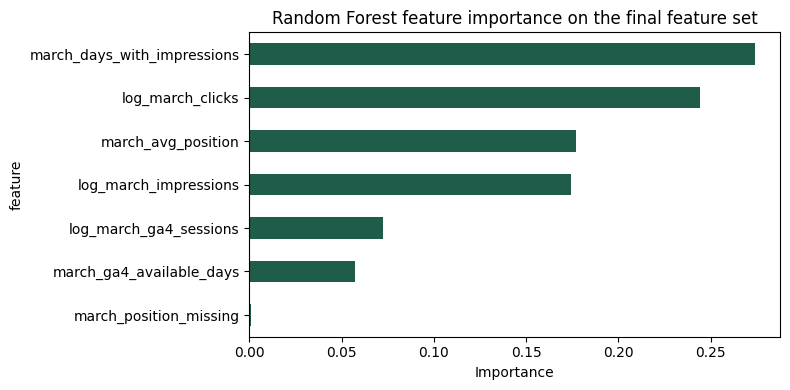

{
  "analysis_month": "2026-03",
  "outcome_month": "2026-04",
  "seed": 42,
  "model_features": [
    "log_march_impressions",
    "log_march_clicks",
    "march_avg_position",
    "march_days_with_impressions",
    "log_march_ga4_sessions",
    "march_ga4_available_days",
    "march_position_missing"
  ],
  "target": "is_declining_next30",
  "group_column": "client_hash_id",
  "future_or_label_features_in_model": [],
  "metrics_file": "work/outputs/capstone_metrics.json",
  "figures": [
    "work/outputs/figures/capstone_model_comparison.png",
    "work/outputs/figures/capstone_feature_importance.png"
  ]
}


In [11]:
# Feature sanity check and paper artifact manifest.
rf = models["random_forest"]
rf_preprocess = rf.named_steps["preprocess"]
rf_model = rf.named_steps["model"]
feature_importance = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

ax = feature_importance.head(7).sort_values("importance").plot(
    kind="barh", x="feature", y="importance", figsize=(8, 4), legend=False, color="#1F5C4A"
)
ax.set_title("Random Forest feature importance on the final feature set")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("work/outputs/figures/capstone_feature_importance.png", dpi=160)
plt.show()

audit_manifest = {
    "analysis_month": ANALYSIS_MONTH,
    "outcome_month": OUTCOME_MONTH,
    "seed": SEED,
    "model_features": MODEL_FEATURES,
    "target": TARGET,
    "group_column": GROUP,
    "future_or_label_features_in_model": [],
    "metrics_file": "work/outputs/capstone_metrics.json",
    "figures": [
        "work/outputs/figures/capstone_model_comparison.png",
        "work/outputs/figures/capstone_feature_importance.png",
    ],
}
Path("work/outputs/capstone_audit_manifest.json").write_text(json.dumps(audit_manifest, indent=2))
print(json.dumps(audit_manifest, indent=2))


## Self-check

Before you submit, confirm each line honestly:

- [ x] Every section above is filled — markdown thinking AND the code that backs it
- [ x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ x] No client names, URLs, or private queries anywhere
- [ x] My claims use careful words: observed, measured, directional, decision-support
- [ x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
